In [1]:
# Requires node.js (https://nodejs.org/en/download)
# Requires dcp, numpy, pandas, matplotlib (pip install dcp numpy pandas matplotlib)
# Requires the local pycomod package (pip install -e OS_PyCoMod_Events)
# Requires a DCP identity/wallet (dcp keystore, or DCP_API_KEY below)

from datetime import datetime
import json
import os
import numpy as np
import pycomod as pcm

# IMPORT AND INIT DCP
import dcp
dcp.init(scheduler='https://scheduler.distributed.computer')
from dcp import identity
from dcp import wallet

# DCP API AND PAYMENT KEYS
# Uses the dcp keystore if present; otherwise set DCP_API_KEY or paste your key here
if not identity.check():
    identity.set(os.environ.get("DCP_API_KEY", "<your_dcp_api_key>"))
wallet.add(wallet.get("default"))

In [2]:
# Initialization dictionary for the multi-fleet model
mf_init = {'run': {'t': [0], # sim start time
            'date': ['2025-11-07'], # sim start date
            'tunit': ['W'], # sim time unit
            'dt': [1], # sim time step
            'end': [52*30], # sim end time
            'reps': [10]}, # sim reps for monte-carlo runs
            'model': {'AC1': ['<model.AC1>'],
            'AC2': ['<model.AC2>'],
            'AC3': ['<model.AC3>'],
            'AC4': ['<model.AC4>']},
            'model.AC1': {'Trg': ['<model.AC1.Trg>'],
            'OTU': ['<model.AC1.OTU>'],
            'G_s': [6,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8], # OTU production
            'O_s': [4,4,4,4,4,4,11,14,19,19,18,18,18,19,19,19,19], # NOP growth
            'Ops': ['<model.AC1.Ops>'],
            'P_s': [33,42,48,55,55,55,55,55,55,55,55,55,55,55,55,55,55], # flying positions
            'Y_s': [3.5,4,4.5,5,5,5,5,5,5,5,5,5,5,5,5,5,5], # YFR in 1000 hrs
            'g': [0.1502403846153846]},
            'model.AC1.Trg': {'F': [0],
            'd': [52],
            's': [0.8],
            'P_0': [0],
            'P_1': [0],
            'P_2': [0],
            'P_3': [0],
            'P_4': [0],
            'P_5': [0],
            'P_6': [0],
            'P_7': [0]},
            'model.AC1.OTU': {'F': [0],
            'd': [26],
            's': [1.0],
            'P_0': [0],
            'P_1': [0],
            'P_2': [0],
            'P_3': [0],
            'P_4': [0],
            'P_5': [0],
            'P_6': [0],
            'P_7': [0]},
            'model.AC1.Ops': {'r_p': [1.9230769230769231],
            'phi': [1],
            'E': [10],
            'N': [35],
            'P': [28],
            'R': [300],
            'a_E': [0.0015384615384615385],
            'a_N': [0.0015384615384615385],
            'g': [0.09615384615384616],
            'h': [0.019230769230769232],
            'mu': [1],
            'r_E': [3.8461538461538463],
            'r_I': [3.8461538461538463],
            'r_Y': [96.15384615384616],
            'th': [2],
            'I_0': [1.875],
            'I_1': [1.875],
            'I_2': [1.875],
            'I_3': [1.875],
            'I_4': [1.875],
            'I_5': [1.875],
            'I_6': [1.875],
            'I_7': [1.875]},
            'model.AC2': {'Trg': ['<model.AC2.Trg>'],
            'OTU': ['<model.AC2.OTU>'],
            'G_s': [6,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8],
            'O_s': [4,4,4,4,4,4,11,14,19,19,18,18,18,19,19,19,19],
            'Ops': ['<model.AC2.Ops>'],
            'P_s': [33,42,48,55,55,55,55,55,55,55,55,55,55,55,55,55,55],
            'Y_s': [3.5,4,4.5,5,5,5,5,5,5,5,5,5,5,5,5,5,5],
            'g': [0.1502403846153846]},
            'model.AC2.Trg': {'F': [0],
            'd': [52],
            's': [0.8],
            'P_0': [0],
            'P_1': [0],
            'P_2': [0],
            'P_3': [0],
            'P_4': [0],
            'P_5': [0],
            'P_6': [0],
            'P_7': [0]},
            'model.AC2.OTU': {'F': [0],
            'd': [26],
            's': [1.0],
            'P_0': [0],
            'P_1': [0],
            'P_2': [0],
            'P_3': [0],
            'P_4': [0],
            'P_5': [0],
            'P_6': [0],
            'P_7': [0]},
            'model.AC2.Ops': {'r_p': [1.9230769230769231],
            'phi': [1],
            'E': [10],
            'N': [35],
            'P': [28],
            'R': [300],
            'a_E': [0.0015384615384615385],
            'a_N': [0.0015384615384615385],
            'g': [0.09615384615384616],
            'h': [0.019230769230769232],
            'mu': [1],
            'r_E': [3.8461538461538463],
            'r_I': [3.8461538461538463],
            'r_Y': [96.15384615384616],
            'th': [2],
            'I_0': [1.875],
            'I_1': [1.875],
            'I_2': [1.875],
            'I_3': [1.875],
            'I_4': [1.875],
            'I_5': [1.875],
            'I_6': [1.875],
            'I_7': [1.875]},
            'model.AC3': {'Trg': ['<model.AC3.Trg>'],
            'OTU': ['<model.AC3.OTU>'],
            'G_s': [6,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8],
            'O_s': [4,4,4,4,4,4,11,14,19,19,18,18,18,19,19,19,19],
            'Ops': ['<model.AC3.Ops>'],
            'P_s': [33,42,48,55,55,55,55,55,55,55,55,55,55,55,55,55,55],
            'Y_s': [3.5,4,4.5,5,5,5,5,5,5,5,5,5,5,5,5,5,5],
            'g': [0.1502403846153846]},
            'model.AC3.Trg': {'F': [0],
            'd': [52],
            's': [0.8],
            'P_0': [0],
            'P_1': [0],
            'P_2': [0],
            'P_3': [0],
            'P_4': [0],
            'P_5': [0],
            'P_6': [0],
            'P_7': [0]},
            'model.AC3.OTU': {'F': [0],
            'd': [26],
            's': [1.0],
            'P_0': [0],
            'P_1': [0],
            'P_2': [0],
            'P_3': [0],
            'P_4': [0],
            'P_5': [0],
            'P_6': [0],
            'P_7': [0]},
            'model.AC3.Ops': {'r_p': [1.9230769230769231],
            'phi': [1],
            'E': [10],
            'N': [35],
            'P': [28],
            'R': [300],
            'a_E': [0.0015384615384615385],
            'a_N': [0.0015384615384615385],
            'g': [0.09615384615384616],
            'h': [0.019230769230769232],
            'mu': [1],
            'r_E': [3.8461538461538463],
            'r_I': [3.8461538461538463],
            'r_Y': [96.15384615384616],
            'th': [2],
            'I_0': [1.875],
            'I_1': [1.875],
            'I_2': [1.875],
            'I_3': [1.875],
            'I_4': [1.875],
            'I_5': [1.875],
            'I_6': [1.875],
            'I_7': [1.875]},
            'model.AC4': {'Trg': ['<model.AC4.Trg>'],
            'OTU': ['<model.AC4.OTU>'],
            'G_s': [6,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8],
            'O_s': [4,4,4,4,4,4,11,14,19,19,18,18,18,19,19,19,19],
            'Ops': ['<model.AC4.Ops>'],
            'P_s': [33,42,48,55,55,55,55,55,55,55,55,55,55,55,55,55,55],
            'Y_s': [3.5,4,4.5,5,5,5,5,5,5,5,5,5,5,5,5,5,5],
            'g': [0.1502403846153846]},
            'model.AC4.Trg': {'F': [0],
            'd': [52],
            's': [0.8],
            'P_0': [0],
            'P_1': [0],
            'P_2': [0],
            'P_3': [0],
            'P_4': [0],
            'P_5': [0],
            'P_6': [0],
            'P_7': [0]},
            'model.AC4.OTU': {'F': [0],
            'd': [26],
            's': [1.0],
            'P_0': [0],
            'P_1': [0],
            'P_2': [0],
            'P_3': [0],
            'P_4': [0],
            'P_5': [0],
            'P_6': [0],
            'P_7': [0]},
            'model.AC4.Ops': {'r_p': [1.9230769230769231],
            'phi': [1],
            'E': [10],
            'N': [35],
            'P': [28],
            'R': [300],
            'a_E': [0.0015384615384615385],
            'a_N': [0.0015384615384615385],
            'g': [0.09615384615384616],
            'h': [0.019230769230769232],
            'mu': [1],
            'r_E': [3.8461538461538463],
            'r_I': [3.8461538461538463],
            'r_Y': [96.15384615384616],
            'th': [2],
            'I_0': [1.875],
            'I_1': [1.875],
            'I_2': [1.875],
            'I_3': [1.875],
            'I_4': [1.875],
            'I_5': [1.875],
            'I_6': [1.875],
            'I_7': [1.875]}}



# DCP work function / pipeline
def build_and_run_model(rep, init, start_date, start_time, end, tunit, dt):
    dcp.progress()
    import numpy as np #type: ignore
    import pycomod as pcm #type: ignore

    # - Generalized multi-step delay with success rate and initial pop
    class Delay(pcm.Model):
        def build(self, steps=8, delay=15, success=0.8, pop=50):
            
            # multi-stage chain of pools
            P_s = [self.pool(pop/steps, pool_type='int', name='P_{z}'.format(z=i)) for i in range(steps)]
            P = self.equation(lambda: sum(P_s)) # total pop
            
            C = self.pool(external=True) # external pool for successful people
            F = self.pool(0, pool_type='int') # pool for unsuccessful people
            
            d = self.parameter(delay) # mean delay parameter
            s = self.parameter(success) # success rate parameter

            # inter-step flows
            F_s = [0]*steps
            for i in range(steps-1):
                F_s[i] = self.flow(eval("lambda: P_s[{z}]*steps/d".format(z=i), locals()), src=P_s[i], dest=P_s[i+1])
        
            F_c = self.flow(lambda: P_s[-1]*steps/d*s, src=P_s[-1], dest=C) # successful flow to ext pool
            F_f = self.flow(lambda: P_s[-1]*steps/d*(1-s), src=P_s[-1], dest=F) #unsuccessful flow to failed pool

            return locals()
        
        
    # MEAD model with generalized multi-step inexperienced pool (u5 removed)
    class MEAD_Ix(pcm.Model):
        def build(self, steps=8, inexp=15, exp=10, nop=35, pos=28):
            
            # time unit for parameters is 1 week
            
            # POOLS
            
            I_s = [self.pool(inexp/steps, name="I_{z}".format(z=i)) for i in range(steps)]
            I = self.equation(lambda: sum(I_s)) # total inexp pop
            
            E = self.pool(exp, pool_type='int') # exp pop
            N = self.pool(nop, pool_type='int') # non-operational positions (NOP)
            
            # PARAMETERS
            
            P = self.parameter(pos) # flying positions
            R = self.parameter(300) # required flying hours to upgrade
            
            g = self.parameter(5/52) # intake rate per timestep
            h = self.parameter(1/52) # other exp losses per timestep
            
            a_E = self.parameter(0.08/52) # exp attrition rate per timestep
            a_N = self.parameter(0.08/52) # NOP attrition rate per timestep
            
            r_I = self.parameter(200/52) # max inexp flying hours per timestep
            r_E = self.parameter(200/52) # max exp mentoring hours per timestep
            r_p = self.parameter(100/52) # min exp flying hours per timestep to maintain proficiency
            r_Y = self.parameter(5000/52) # max total flying hours per timestep
            
            mu = self.parameter(1) # mentee-hour:mentor-hour ratio
            th = self.parameter(2) # inexp yfr cost (including mentoring)
            phi = self.parameter(1) # exp yfr cost
            
            # EQUATIONS
            
            u1 = self.equation(lambda: r_I*I/R) # mentee-limited
            u2 = self.equation(lambda: r_E*mu*E/R) # mentor-limited
            u3 = self.equation(lambda: max(0, r_E*mu*(P-I)/R)) # position-limited
            u4 = self.equation(lambda: r_Y/th/R) # YFR-limited

            u = self.equation(lambda: min(u1, u2, u3, u4)) # net upgrade rate to exp
            u_s = self.equation(lambda: u*steps/I) # inexp step flows

            # FLOWS
            
            # disable this flow because intake is coming from OTU model
            #F_g = self.flow(lambda: g, dest=I_s[0], discrete=True, stochastic=False) # OTU production flow
            
            # experience accumulation and upgrade
            F_s = [0]*steps
            for i in range(steps-1):
                F_s[i] = self.flow(eval("lambda: I_s[{z}]*u_s".format(z=i), locals()), src=I_s[i], dest=I_s[i+1])

            F_u = self.flow(lambda: I_s[-1]*u_s, src=I_s[-1], dest=E)

            F_h = self.flow(lambda: h, src=E) # other loss flow
            F_aE = self.flow(lambda: E*a_E, src=E, stochastic=True) # exp attrition flow
            F_aN = self.flow(lambda: N*a_N, src=N, stochastic=True) # NOP attrition flow
            F_EN = self.flow(lambda: F_aN, src=E, dest=N) # posting to NOP flow replacing NOP attrition
            
            # OTHER OUTPUTS
            
            I_ss = self.equation(lambda: g*R/r_I) # inexp steady state
            E_ss = self.equation(lambda: (g - h - a_N*N)/a_E) # exp steady state
            
            E_cor = self.equation(lambda: E if I + E <= P else P - I) # corrected exp pop
            N_cor = self.equation(lambda: N if I + E <= P else N + I + E - P) # corrected NOP pop
            
            E_crit = self.equation(lambda: (h + a_N*N)/(r_E*mu/R - a_E)) # critical min exp pop
            I_crit = self.equation(lambda: P - g*R/r_E/mu) # critical max inexp pop
            
            IE = self.equation(lambda: I+E)

            return locals()
        
        
    # Fleet model consisting of training and OTU delays and a MEAD model of the ops squadron
    class Fleet(pcm.Model):
        def build(self):
            
            # time unit is weeks
            
            # submodels
            Trg = self.submodel(Delay(steps=8, delay=52, success=0.8, pop=0))
            OTU = self.submodel(Delay(steps=8, delay=26, success=1.0, pop=0))
            Ops = self.submodel(MEAD_Ix(steps=8, inexp=15, exp=10, nop=35, pos=28))

            # limit tracked output; must be set post-construction
            Trg.set_output('P')
            OTU.set_output('P')
            Ops.set_output('I', 'E', 'N', 'P', 'I_ss', 'E_ss', 'IE')

            # connect submodels
            Trg.connect(C=OTU.P_s[0])
            OTU.connect(C=Ops.I_s[0])

            # intake to training
            g = self.parameter(7.8125/52)
            Fin = self.flow(lambda: g, dest=Trg.P_s[0])
            
            # position schedule
            P_s = self.parameter([0]) # flying positions
            O_s = self.parameter([0]) # additional NOP on top of N
            G_s = self.parameter([0]) # intake plan
            Y_s = self.parameter([0]) # YFR
            
            @self.process(start=self.wait_sim_start())
            def pos():
                for i in range(17):
                    Ops.P.set(P_s[i])
                    Ops.h.set(O_s[i]*Ops.a_N)
                    Ops.r_Y.set(Y_s[i]*1000/52)
                    g.set(G_s[i]/0.8/52)
                    Ops.g.set(G_s[i]/52)
                    yield self.wait_delay(52)

            return locals()

    # Multi-fleet model
    class MultiFleet(pcm.Model):
        def build(self):
            AC1 = self.submodel(Fleet())
            AC2 = self.submodel(Fleet())
            AC3 = self.submodel(Fleet())
            AC4 = self.submodel(Fleet())

            # limit output; written out to avoid a loop-var leaking into locals()
            AC1.set_output('Trg', 'OTU', 'Ops')
            AC2.set_output('Trg', 'OTU', 'Ops')
            AC3.set_output('Trg', 'OTU', 'Ops')
            AC4.set_output('Trg', 'OTU', 'Ops')

            return locals()


    mf = MultiFleet()

    mf._run(end, dt, tunit, start_time, start_date, init)

    # drop redundant per-leaf 'dates' (derivable from 'times') to cut payload size
    def strip_dates(d):
        for v in d.values():
            if isinstance(v, dict):
                v.pop('dates', None)
                strip_dates(v)
    strip_dates(mf._output)

    # mf.t/mf.date never accumulate real history in this pycomod version; borrow a
    # tracked leaf's 'times' instead
    if rep == 0:
        x_times = np.array(mf._output['AC1']['Trg']['P']['times'])
        # use day precision; float * timedelta64['W'] truncates fractional weeks
        tunit_days = mf.tunit.init_value / np.timedelta64(1, 'D')
        elapsed_days = np.round(x_times * tunit_days).astype('int64')
        x_dates = mf.date.init_value + elapsed_days.astype('timedelta64[D]')

    result = {
        '_output': mf._output,
        **({
            'model_type': type(mf).__name__,
            'x_times': x_times,
            'x_dates': x_dates,
        } if rep == 0 else {}),
    }

    # manually clear everything and force garbage collection
    del mf
    import gc
    gc.collect()

    return result



print("Model and pipeline ready")

Model and pipeline ready


In [5]:
# repitions to perform in the Monte Carlo simulation
reps = range(10)

# define DCP Job handle that maps build_and_run_model along with args to all the reps init, start_date, start_time, end, tunit, dt
run_start_date = '2025-11-07'
run_tunit = 'W'

# DCP JOB
job = dcp.compute_for(reps, build_and_run_model, [mf_init, run_start_date, 0, 52*30, run_tunit, 1])

# JOB CONFIG
job.public.name = '🪖 Multi-fleet'
job.fs.add('./OS_PyCoMod_Events/pycomod')
job.modules = ['numpy', 'pandas']
job.computeGroups = [
    {'joinKey':'demo', 'joinSecret':'dcp'}
]

# EVENTS
job.on('readystatechange', lambda s: print(f"State: {s}"))
job.on('accepted', lambda _: print(f"\nJob ID: {job.id}\nJob accepted, awaiting results..."))
job.on('error', lambda e: print(json.dumps(e, indent=4).replace('\\n', '\n')))
job.on('result', lambda r: print(f"Computed result {int(r.sliceNumber)} of {len(reps)}"))
job.on('nofunds', lambda n: print(json.dumps(n, indent=4).replace('\\n', '\n')))

# EXEC
job.exec(0.01)
results = job.wait()



print('Done.')

deployed            
Job ID: wd0RqjEW3NO6lc8t8xw0qx
Job accepted, awaiting results...
Computed result 1 of 10
Computed result 2 of 10
Computed result 3 of 10
Computed result 5 of 10
Computed result 4 of 10
Computed result 6 of 10
Computed result 7 of 10
Computed result 8 of 10
Computed result 9 of 10
Computed result 10 of 10
Done.


In [6]:
# Show result data size if curious
import sys
import numpy as np

def total_size(obj, seen=None):
    if seen is None:
        seen = set()
    obj_id = id(obj)
    if obj_id in seen:
        return 0
    seen.add(obj_id)

    if isinstance(obj, np.ndarray):
        return obj.nbytes

    size = sys.getsizeof(obj)

    if isinstance(obj, dict):
        size += sum(total_size(k, seen) + total_size(v, seen) for k, v in obj.items())
    elif isinstance(obj, (list, tuple, set)):
        size += sum(total_size(i, seen) for i in obj)
    elif hasattr(obj, "__dict__"):
        size += total_size(obj.__dict__, seen)

    return size


# compute size
bytes_size = total_size(results)
mb_size = bytes_size / (1024 ** 2)

print("Size (MB):", mb_size)


Size (MB): 5.844099044799805


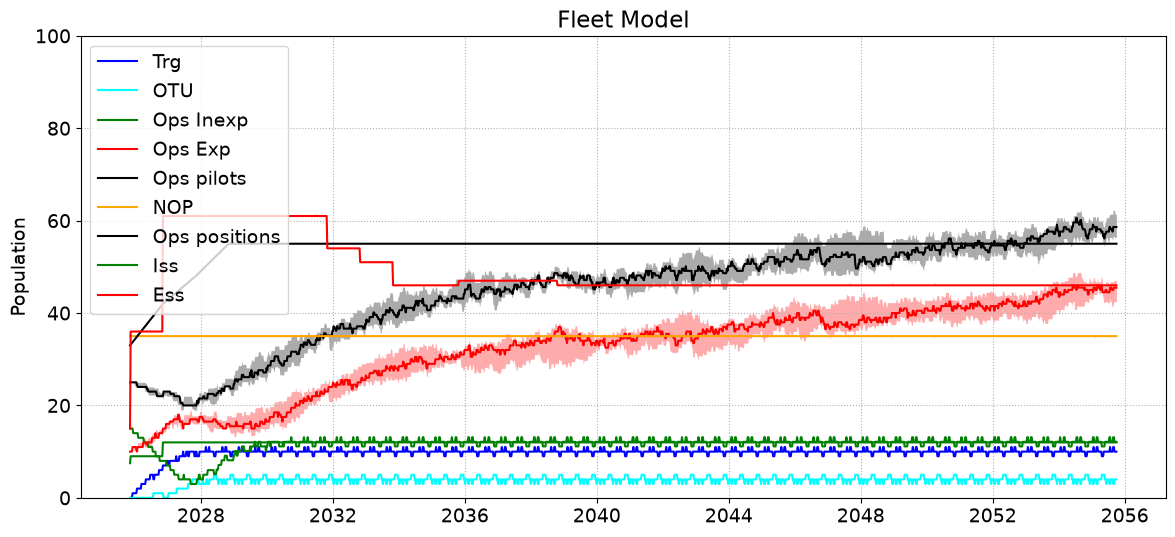

In [5]:
# Build _output_mc from DCP results, recursively.
# Works for any model structure.
def build_mc_output_generic(results):

    # derive dates per leaf; elements update on different cadences
    tunit_days = {'D': 1, 'W': 7}[run_tunit]
    def dates_from_times(times):
        elapsed_days = np.round(np.array(times) * tunit_days).astype('int64')
        return np.datetime64(run_start_date) + elapsed_days.astype('timedelta64[D]')

    def recurse(structure, path=()):
        out = {}
        for key, val in structure.items():
            current_path = path + (key,)
            
            if isinstance(val, dict) and 'values' in val:
                # Leaf with values
                mc_values = np.array([
                    get_from_path(r['_output'], current_path)['values']
                    for r in results
                ], dtype=float)
                mc_times = val.get('times', results[0].get('x_times'))
                mc_dates = dates_from_times(mc_times)
                out[key] = {
                    'mc_values': mc_values,
                    'mc_times': mc_times,
                    'mc_dates': mc_dates
                }
            elif isinstance(val, dict):
                # Recurse into nested dict
                out[key] = recurse(val, path=current_path)
            else:
                # Plain numeric leaf
                mc_values = np.array([
                    get_from_path(r['_output'], current_path)
                    for r in results
                ], dtype=float)
                out[key] = {
                    'mc_values': mc_values,
                    'mc_times': results[0].get('x_times'),
                    'mc_dates': results[0].get('x_dates')
                }
        return out

    def get_from_path(d, path):
        """Utility: traverse nested dict using a tuple path"""
        for p in path:
            d = d[p]
        return d

    # Top level: just recurse whatever is in results[0]['_output']
    return recurse(results[0]['_output'])

_output_mc = build_mc_output_generic(results)


# Build run_data dict from _output_mc and DCP results
run_data = {
    'output_mc': _output_mc,
    'model': results[0]['model_type'],
    'init_hash': hash("dcp_run"),
    'timestamp': str(datetime.now()),
    'reps': len(results),
    'x_times': results[0]['x_times'],
    'x_dates': results[0]['x_dates']
}

# made mgr dict just so the plot calls are identical to the example
mgr = {}
mgr[job.public.name] = run_data


# Plot
run = job.public.name  # must match the mgr[job.public.name] = run_data key above
output = 'output_mc'
fleet = 'AC2'

plt = pcm.Plotter(title='Fleet Model', ylabel='Population', fontsize=14, ylimit=[0,100], xdates=True)
plt.plot(mgr[run][output][fleet]['Trg']['P'], color='blue', interval=50, label='Trg', step=True)
plt.plot(mgr[run][output][fleet]['OTU']['P'], color='cyan', interval=50, label='OTU', step=True)
plt.plot(mgr[run][output][fleet]['Ops']['I'], color='green', interval=50, label='Ops Inexp', step=True)
plt.plot(mgr[run][output][fleet]['Ops']['E'], color='red', interval=50, label='Ops Exp', step=True)
plt.plot(mgr[run][output][fleet]['Ops']['IE'], color='black', interval=50, label='Ops pilots', step=True)
plt.plot(mgr[run][output][fleet]['Ops']['N'], color='orange', interval=50, label='NOP', step=True)
plt.plot(mgr[run][output][fleet]['Ops']['P'], color='black', interval=50, linestyle='--', label='Ops positions', step=True)
plt.plot(mgr[run][output][fleet]['Ops']['I_ss'], color='green', interval=50, linestyle=':', label='Iss', step=True)
plt.plot(mgr[run][output][fleet]['Ops']['E_ss'], color='red', interval=50, linestyle=':', label='Ess', step=True)
plt.show()